# M6 — Capacity / Demand / Cost What-If Decision Support

**Goal.** Turn the diagnosis (M4 constraint = S4) and the simulator into **decisions**:
which improvement to make, why, and at what cost. Every experiment reuses the **M4 CRN
counterfactual harness** (N=30 replications, one shared draw table per rep, paired Δ,
95% CI) — the simulator is not rewritten — plus a simple, transparent cost model.

**Structure (kept deliberately separate):**
1. **Capacity what-if + cost** — +1 tool at S4 vs non-bottlenecks, now costed.
2. **Demand what-if (descriptive)** — what rising demand *does*: which station saturates
   first, the non-linear cycle-time blow-up, and why adding bottleneck capacity only lifts
   throughput once the bottleneck saturates (closing the M4 arrival-limited thread).
3. **Degradation impact** — the cost of a slowly degrading bottleneck, and what early
   detection (M5) is worth.
4. **Improvement trade-off (prescriptive, fixed output)** — at equal output, rank the
   improvement options by total cost, with a ±50% cost-rate sensitivity.

**Cost model** = three transparent components (processing, waiting/holding, capacity),
with a one-off repair cost for the early-fix option. **All rates are illustrative
assumptions; cost is used to RANK options relatively, not to predict absolute dollars.**

**Honest boundary.** The real 4TU log has no tool counts, arrival process, or cost data,
so what-if and cost are impossible on it. M6 runs entirely on the **synthetic** line and is
a decision-support *methodology* demo, not a real-factory forecast.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

ROOT = Path("..")
for p in ["src","src/generator","src/bottleneck","src/monitoring","src/decision"]:
    sys.path.insert(0, str(ROOT/p))

from factory_generator import default_config, draw_randoms, simulate, DegradationAnomaly
from counterfactual import summarize
from m5_config import m5_config
import kpi_series as ks, detectors as det, whatif as wf
from cost_model import CostRates, cost_components, daily_operating_cost

FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)
N = 30
RATES = CostRates()
print("cost rates (ILLUSTRATIVE):", RATES.__dict__)

C:\Users\User\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


cost rates (ILLUSTRATIVE): {'proc_rate': 100.0, 'hold_rate': 10.0, 'tool_cost': 20000.0, 'repair_cost': 2000.0}


## Step 1 — Capacity what-if, now costed

The M4 counterfactual (+1 tool at S4 vs the controls S3/S7), paired Δ over N=30, with the
net **Δ total cost** of each decision (machine cost minus any congestion savings).

,Δcycle_time(h),Δcost($)
intervention,,
S4+1,-2.4,-10582.3
S3+1,-0.1,18117.5
S7+1,-0.0,19375.2


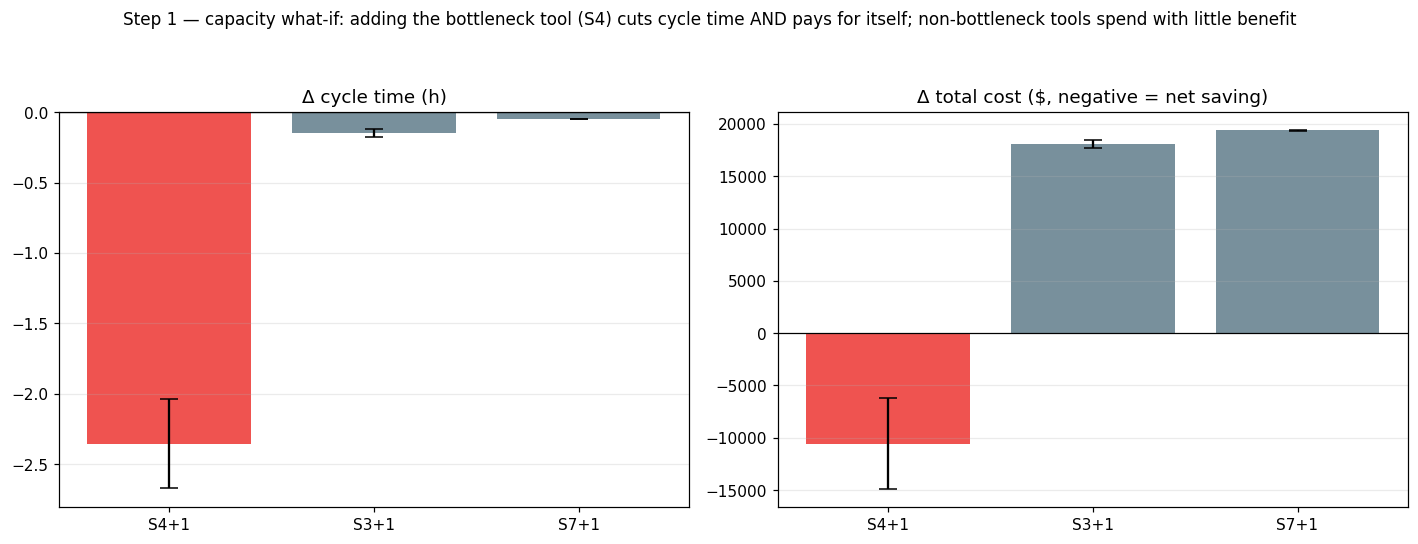

In [2]:
cap = wf.run_capacity_cost(default_config(), n_reps=N, rates=RATES)
ct = summarize(cap, "d_cycle_time"); cost = summarize(cap, "d_cost")
display(pd.concat({"Δcycle_time(h)": ct["mean"], "Δcost($)": cost["mean"]}, axis=1).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = list(ct.index)
col = ["#EF5350" if l.startswith("S4") else "#78909C" for l in labels]
axes[0].bar(labels, ct["mean"], yerr=ct["ci95_half"], capsize=6, color=col)
axes[0].axhline(0, color="k", lw=.8); axes[0].set_title("Δ cycle time (h)"); axes[0].grid(axis="y", alpha=.25)
axes[1].bar(labels, cost["mean"], yerr=cost["ci95_half"], capsize=6, color=col)
axes[1].axhline(0, color="k", lw=.8); axes[1].set_title("Δ total cost ($, negative = net saving)")
axes[1].grid(axis="y", alpha=.25)
fig.suptitle("Step 1 — capacity what-if: adding the bottleneck tool (S4) cuts cycle time AND "
             "pays for itself; non-bottleneck tools spend with little benefit", fontsize=11)
fig.tight_layout(rect=(0,0,1,0.93)); fig.savefig(FIG/"capacity_cost_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()

**Reading.** Relieving S4 has by far the largest cycle-time benefit and, at these
illustrative rates, its congestion savings **exceed the machine cost** (net Δcost < 0).
Buying a tool at a non-bottleneck (S3/S7) spends the capital with almost no benefit — the
cost signature of misallocated capacity.

## Step 2 — Demand what-if (descriptive)

What does rising demand do? Utilization is exact analytically: ρ_s = arrival · factor ·
visits_s · pt_s / n_tools_s.

,1.00,1.10,1.25,1.50
S1,0.50,0.550,0.625,0.750
S2,0.60,0.660,0.750,0.900
S3,0.65,0.715,0.812,0.975
S4,0.85,0.935,1.062,1.275
S5,0.50,0.550,0.625,0.750
S6,0.55,0.605,0.688,0.825
S7,0.45,0.495,0.562,0.675


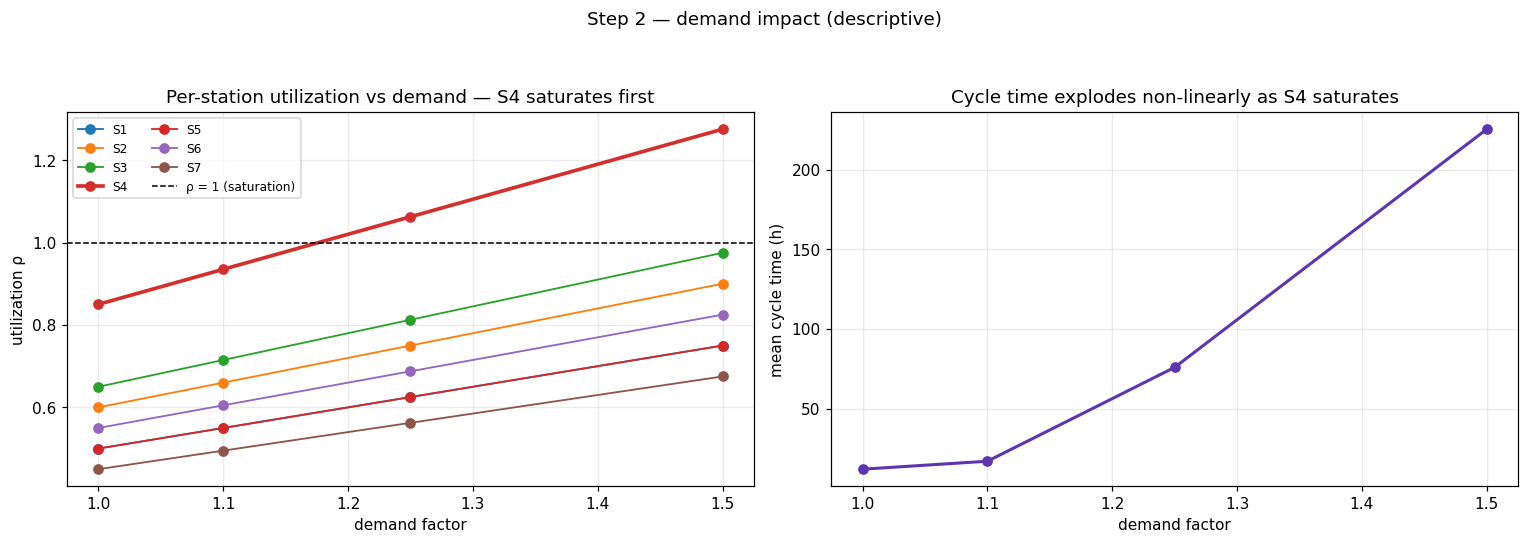

throughput saturates at the S4 capacity limit:
        throughput  cycle_time
factor                        
1.00         0.995      11.966
1.10         1.095      16.968
1.25         1.149      75.885
1.50         1.081     225.332


In [3]:
factors = [1.0, 1.10, 1.25, 1.50]
util = wf.utilization_vs_demand(default_config(), factors)
display(util.round(3))

dem = wf.run_demand_absolute(default_config(), factors, n_reps=N)
dem_m = dem.groupby("factor")[["throughput","cycle_time"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s in util.index:
    axes[0].plot(factors, util.loc[s], "o-", label=s, lw=(2.4 if s=="S4" else 1.2),
                 color=("#D32F2F" if s=="S4" else None))
axes[0].axhline(1.0, color="k", ls="--", lw=1, label="ρ = 1 (saturation)")
axes[0].set_xlabel("demand factor"); axes[0].set_ylabel("utilization ρ")
axes[0].set_title("Per-station utilization vs demand — S4 saturates first"); axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=.25)
axes[1].plot(dem_m.index, dem_m["cycle_time"], "o-", color="#5E35B1", lw=2)
axes[1].set_xlabel("demand factor"); axes[1].set_ylabel("mean cycle time (h)")
axes[1].set_title("Cycle time explodes non-linearly as S4 saturates"); axes[1].grid(alpha=.25)
fig.suptitle("Step 2 — demand impact (descriptive)", fontsize=12)
fig.tight_layout(rect=(0,0,1,0.93)); fig.savefig(FIG/"demand_saturation.png", bbox_inches="tight", dpi=150)
plt.show()
print("throughput saturates at the S4 capacity limit:")
print(dem_m.round(3).to_string())

Once demand pushes S4 to ρ ≥ 1 (here at ~×1.25) the line is bottleneck-limited:
throughput caps at S4's capacity and cycle time blows up (unstable — measured on completed
lots). Now the key contrast with M4: **does adding S4 capacity lift throughput?**

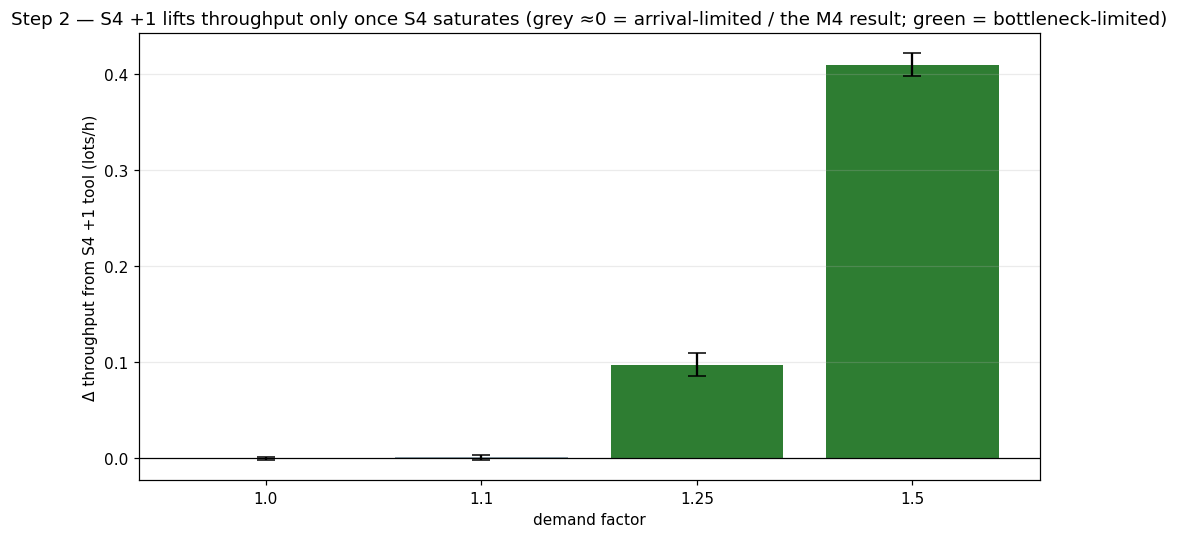

,mean,ci
factor,,
1.00,-0.0004,0.0012
1.10,0.0008,0.0027
1.25,0.0974,0.0116
1.50,0.4099,0.0116


In [4]:
dcap = wf.run_demand_capacity(default_config(), factors, n_reps=N, station="S4")
dcap_m = dcap.groupby("factor")["d_throughput"].agg(["mean","sem"])
dcap_m["ci"] = dcap_m["sem"]*1.96

fig, ax = plt.subplots(figsize=(9, 5))
col = ["#90A4AE" if f < 1.25 else "#2E7D32" for f in factors]
ax.bar([str(f) for f in factors], dcap_m["mean"], yerr=dcap_m["ci"], capsize=6, color=col)
ax.axhline(0, color="k", lw=.8)
ax.set_xlabel("demand factor"); ax.set_ylabel("Δ throughput from S4 +1 tool (lots/h)")
ax.set_title("Step 2 — S4 +1 lifts throughput only once S4 saturates "
             "(grey ≈0 = arrival-limited / the M4 result; green = bottleneck-limited)")
ax.grid(axis="y", alpha=.25)
fig.tight_layout(); fig.savefig(FIG/"demand_capacity_throughput.png", bbox_inches="tight", dpi=150)
plt.show()
display(dcap_m[["mean","ci"]].round(4))

**Reading.** At ×1.0–×1.10 (S4 still below 1) extra S4 capacity barely moves throughput —
exactly the arrival-limited result from M4. Once S4 saturates (×1.25, ×1.50) the same tool
delivers a large, significant throughput gain. Capacity helps throughput **only when the
bottleneck is the binding constraint.**

## Step 3 — Degradation impact and the value of early detection

A slowly degrading S4 (processing time ramps up from day 30, kept gentle so output stays
fixed) is injected with the M5 mechanism. We run the **same M5 EWMA detector** on the
degrading line to get an honest detection day, then quantify the cost.

degradation onset day 30; M5 EWMA flags it on day 84
  d_cost        : +184576.23  (95% CI ±33369.37)
  d_cycle_time  : +4.06  (95% CI ±0.87)
  d_throughput  : -0.00  (95% CI ±0.00)


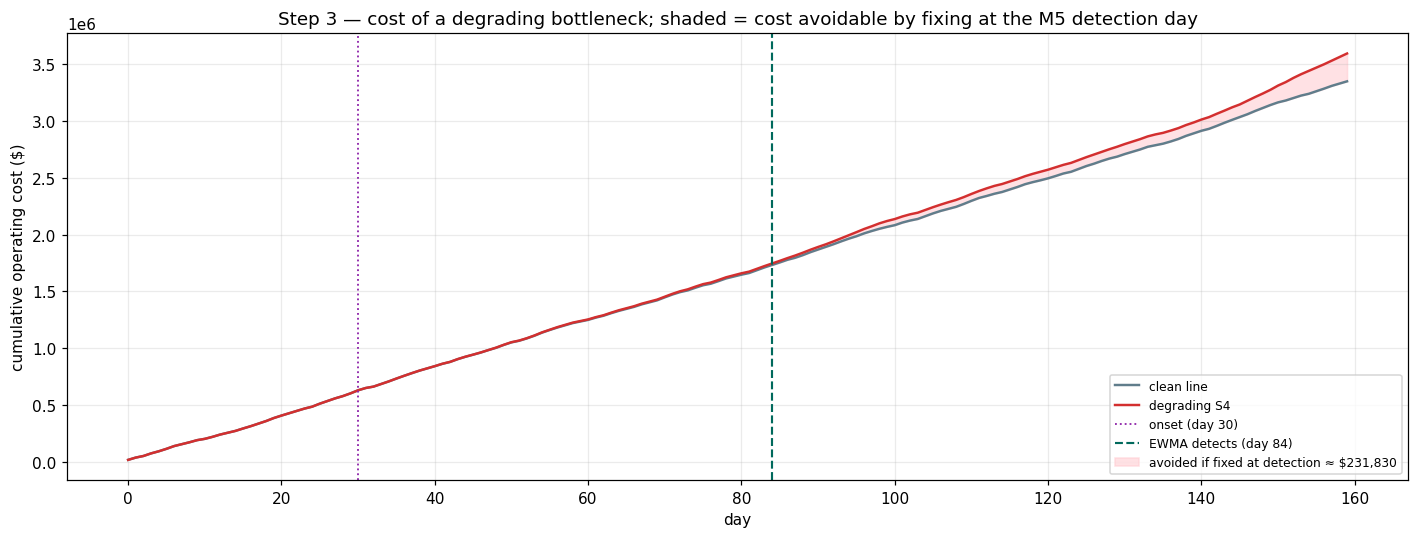

reference run: total extra cost of degradation ≈ $245,061; avoidable by fixing at detection ≈ $231,830


In [5]:
cfg = m5_config(horizon_days=160, warmup_days=6)
ONSET_D = 30
deg = DegradationAnomaly("S4", ONSET_D*24.0, cfg.horizon_hours, alpha=5e-5)

# honest monitoring link: detection day from M5 EWMA on the degrading cycle-time series
draws_ref = draw_randoms(cfg, 4000)
log_c0, life_c0, _ = simulate(cfg, draws_ref)
log_d0, life_d0, _ = simulate(cfg, draws_ref, anomalies=[deg])
dser = ks.daily_kpis(log_d0, life_d0, cfg)["cycle_time"]
c_, sg_ = det.fit_baseline(dser, list(range(6, ONSET_D-2)))
ew = det.ewma_chart(dser, c_, sg_, lam=0.2, L=3.0)
DET_DAY = [d for d in ew.index[ew["alarm"]] if d >= ONSET_D][0]
print(f"degradation onset day {ONSET_D}; M5 EWMA flags it on day {DET_DAY}")

imp = wf.run_degradation_impact(cfg, deg, n_reps=N, rates=RATES)
for m in ["d_cost","d_cycle_time","d_throughput"]:
    s = summarize(imp, m).loc["degradation"]
    print(f"  {m:14s}: {s['mean']:+.2f}  (95% CI ±{s['ci95_half']:.2f})")

# cost-over-time on the reference pair, with avoided-cost from fixing at detection
clean_cum = daily_operating_cost(log_c0, cfg.horizon_hours, RATES).cumsum()
deg_cum = daily_operating_cost(log_d0, cfg.horizon_hours, RATES).cumsum()
extra_end = deg_cum.iloc[-1] - clean_cum.iloc[-1]
extra_at_det = deg_cum.loc[DET_DAY] - clean_cum.loc[DET_DAY]
avoided = extra_end - extra_at_det

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(clean_cum.index, clean_cum.values, color="#607D8B", lw=1.6, label="clean line")
ax.plot(deg_cum.index, deg_cum.values, color="#D32F2F", lw=1.6, label="degrading S4")
ax.axvline(ONSET_D, color="#8E24AA", ls=":", lw=1.2, label=f"onset (day {ONSET_D})")
ax.axvline(DET_DAY, color="#00695C", ls="--", lw=1.4, label=f"EWMA detects (day {DET_DAY})")
ax.fill_between(deg_cum.index, clean_cum.values, deg_cum.values,
                where=(deg_cum.index >= DET_DAY), color="#FFCDD2", alpha=.6,
                label=f"avoided if fixed at detection ≈ ${avoided:,.0f}")
ax.set_xlabel("day"); ax.set_ylabel("cumulative operating cost ($)")
ax.set_title("Step 3 — cost of a degrading bottleneck; shaded = cost avoidable by fixing "
             "at the M5 detection day")
ax.legend(fontsize=8); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIG/"degradation_cost_over_time.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"reference run: total extra cost of degradation ≈ ${extra_end:,.0f}; "
      f"avoidable by fixing at detection ≈ ${avoided:,.0f}")

**Reading.** A gentle degradation that barely touches output still accumulates a large
congestion cost. Because it is subtle, EWMA flags it only well after onset — but fixing at
that point still avoids the shaded cost. This is the concrete link from **monitoring (M5)**
to **money**.

## Step 4 — Improvement trade-off (prescriptive, fixed output)

All options must deliver the **same output**; we then compare **total cost**. Demand control
is deliberately **excluded** — it would "win" only by serving less demand, i.e. by not meeting
the output target, which is not an operational improvement. The options:
- **add_S4** — +1 tool at the bottleneck (compensate the degradation),
- **add_S3** — +1 tool at a non-bottleneck (spend, little benefit),
- **early_fix** — detect (M5) and repair the degradation at the detection day (+ repair cost),
- **do_nothing** — let it degrade (reference).

throughput per option (fixed-output check — all ≈ equal):
option
add_S3        0.9948
add_S4        1.0006
do_nothing    0.9948
early_fix     1.0009


,mean,ci95_half
intervention,,
add_S4,3155544.0,20813.0
early_fix,3214584.0,29213.0
do_nothing,3382096.0,54435.0
add_S3,3396789.0,54596.0


RECOMMENDED (lowest cost at equal output): add_S4


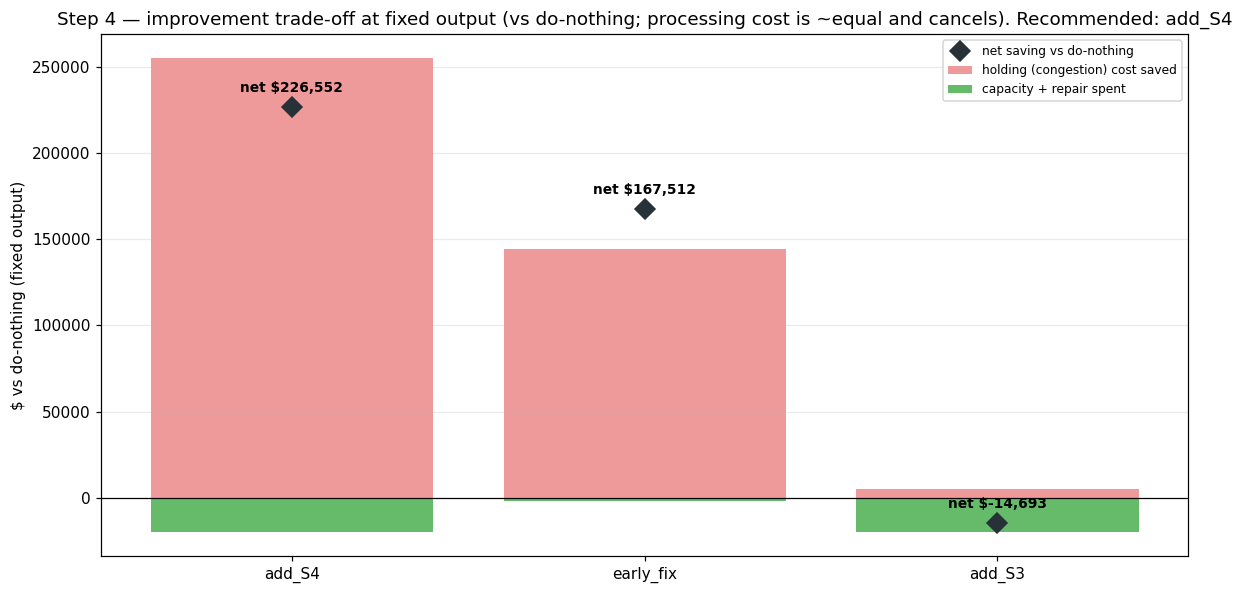

absolute mean total cost per option ($): {'add_S4': 3155544.0, 'early_fix': 3214584.0, 'do_nothing': 3382096.0, 'add_S3': 3396789.0}


In [6]:
raw = wf.run_improvement_raw(cfg, deg, DET_DAY, n_reps=N, nonbottleneck="S3")
thr = raw.groupby("option")["throughput"].mean()
print("throughput per option (fixed-output check — all ≈ equal):")
print(thr.round(4).to_string())

summ = wf.tradeoff_summary(raw, RATES)
display(summ[["mean","ci95_half"]].round(0))
REC = wf.recommended_option(raw, RATES)
print("RECOMMENDED (lowest cost at equal output):", REC)

# stacked cost components per option
# Processing cost is ~equal across options (same output), so it swamps the decision-
# relevant differences in an absolute bar. Show COST SAVING vs do-nothing (processing
# cancels) — this isolates what the decision actually changes.
means = summ["mean"]
dn = means["do_nothing"]
order = ["add_S4", "early_fix", "add_S3"]
saving = (dn - means[order])            # positive = cheaper than doing nothing
# decompose the saving into holding saved (good) vs capacity+repair spent (cost)
comp = raw.assign(
    holding=raw["wait_hours"]*RATES.hold_rate,
    spend=raw["tools_added"]*RATES.tool_cost + raw["repairs"]*RATES.repair_cost,
).groupby("option")[["holding","spend"]].mean()
hold_saved = comp.loc["do_nothing","holding"] - comp.loc[order,"holding"]
spend = comp.loc[order,"spend"]

fig, ax = plt.subplots(figsize=(11, 5.5))
xo = np.arange(len(order))
ax.bar(xo, hold_saved, color="#EF9A9A", label="holding (congestion) cost saved")
ax.bar(xo, -spend, color="#66BB6A", label="capacity + repair spent")
ax.plot(xo, saving.values, "D", color="#263238", ms=9, label="net saving vs do-nothing")
for i, v in enumerate(saving.values):
    ax.annotate(f"net ${v:,.0f}", (i, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, fontweight="bold")
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(xo); ax.set_xticklabels(order)
ax.set_ylabel("$ vs do-nothing (fixed output)")
ax.set_title(f"Step 4 — improvement trade-off at fixed output (vs do-nothing; processing "
             f"cost is ~equal and cancels). Recommended: {REC}")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=.25)
fig.tight_layout(); fig.savefig(FIG/"improvement_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"absolute mean total cost per option ($): {means.round(0).to_dict()}")

### Sensitivity — does the recommendation survive ±50% on each rate?

Because cost is linear in the rates, we re-cost the **same simulated runs** with each rate
scaled ±50% (no re-simulation) and check whether the recommended option flips.

,scenario,recommended,add_S4,early_fix,do_nothing,add_S3
0,baseline,add_S4,3155544.0,3214584.0,3382096.0,3396789.0
1,proc_rate x0.5,add_S4,1617240.0,1693257.0,1848038.0,1862748.0
2,proc_rate x1.5,add_S4,4693849.0,4735912.0,4916154.0,4930831.0
3,hold_rate x0.5,add_S4,3126077.0,3129620.0,3225106.0,3242436.0
4,hold_rate x1.5,add_S4,3185012.0,3299549.0,3539086.0,3551143.0
5,tool_cost x0.5,add_S4,3145544.0,3214584.0,3382096.0,3386789.0
6,tool_cost x1.5,add_S4,3165544.0,3214584.0,3382096.0,3406789.0
7,repair_cost x0.5,add_S4,3155544.0,3213584.0,3382096.0,3396789.0
8,repair_cost x1.5,add_S4,3155544.0,3215584.0,3382096.0,3396789.0


recommended option across ALL scenarios: ['add_S4']


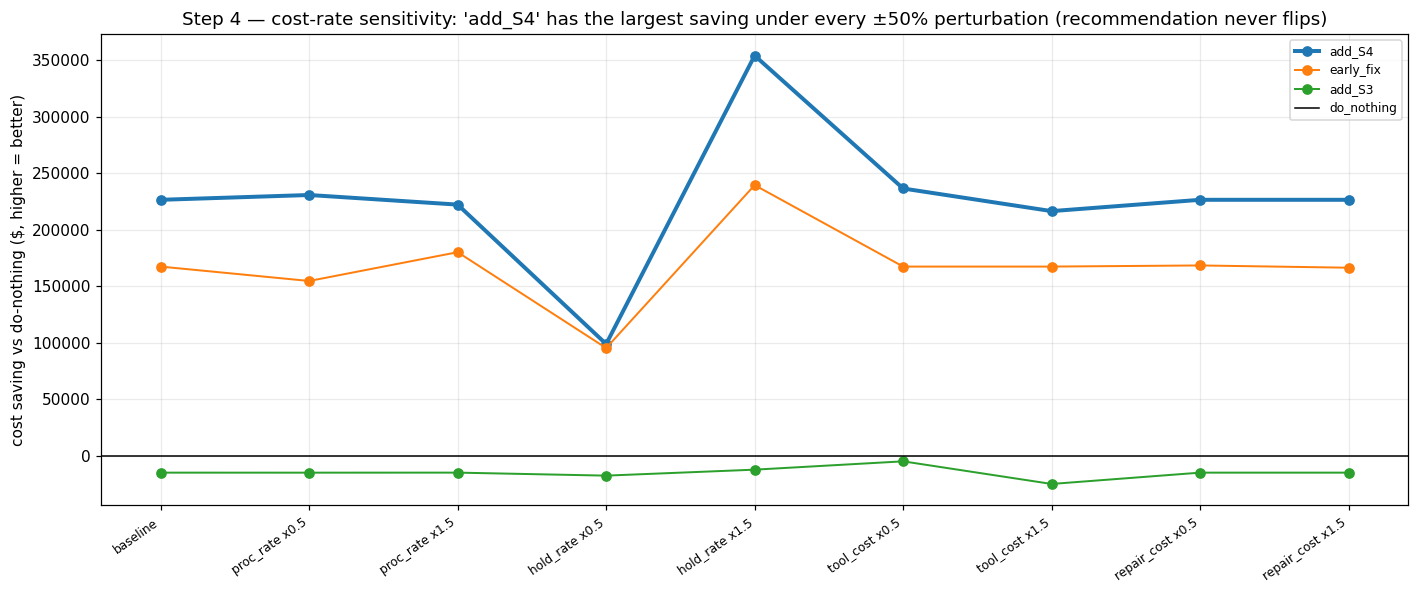

In [7]:
sens = wf.sensitivity_recommendation(raw, RATES)
display(sens.round(0))
print("recommended option across ALL scenarios:", sorted(set(sens["recommended"])))

# Plot saving vs do-nothing per option across scenarios (do_nothing = 0 baseline),
# so the lines separate and 'always highest saving' = 'never flips'.
opts = ["add_S4", "early_fix", "add_S3"]
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(sens))
for o in opts:
    saving_line = sens["do_nothing"] - sens[o]
    ax.plot(x, saving_line, "o-", label=o, lw=(2.6 if o == REC else 1.3))
ax.axhline(0, color="k", lw=1.0, label="do_nothing")
ax.set_xticks(x); ax.set_xticklabels(sens["scenario"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("cost saving vs do-nothing ($, higher = better)")
ax.set_title(f"Step 4 — cost-rate sensitivity: '{REC}' has the largest saving under every "
             f"±50% perturbation (recommendation never flips)")
ax.legend(fontsize=8); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIG/"cost_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

**Reading.** At equal output, **adding a tool at the bottleneck S4 is the lowest-cost
improvement**, and that recommendation is unchanged under every ±50% rate perturbation — a
robust decision, not an artefact of one cost assumption. Early detection-and-fix is the
next best and clearly beats doing nothing (the monitoring payoff); spending on a
non-bottleneck tool is the worst.

## Step 5 — Honest boundary

Everything above runs on the **synthetic** line, whose capacities, arrival process, and
(illustrative) cost rates are known. The real 4TU log has **none** of these — no declared
tool counts, no arrival model, no cost data — so what-if scenarios and cost ranking **cannot**
be computed on it. M6 is a demonstration of a decision-support *methodology* against a known
ground truth; it is **not** a cost forecast for any real factory. The transferable output is
the method: use the constraint (M4) + a CRN what-if + a transparent, sensitivity-tested cost
model to rank improvements by cost at fixed output.

## Summary

| Step | Output |
|---|---|
| 1 Capacity + cost | S4 +1 cuts cycle time most and pays for itself; non-bottleneck tools waste capital |
| 2 Demand (descriptive) | S4 saturates first; cycle time explodes non-linearly; S4 capacity lifts throughput only once saturated (closes M4 thread) |
| 3 Degradation | a gentle S4 degradation adds large congestion cost; EWMA (M5) detection enables an avoidable-cost saving |
| 4 Trade-off (fixed output) | at equal output, **add S4 capacity** is lowest-cost and robust to ±50% rate changes; demand control excluded by design |
| 5 Boundary | synthetic-only methodology demo; real log cannot support what-if/cost |

**Figures (`reports/figures/`):** `capacity_cost_tradeoff.png`, `demand_saturation.png`,
`demand_capacity_throughput.png`, `degradation_cost_over_time.png`,
`improvement_tradeoff.png`, `cost_sensitivity.png`.

**Method integrity:** reuses the M4 CRN harness (paired Δ, 95% CI); cost = 3 transparent
components with illustrative rates used for relative ranking only; every recommendation is
sensitivity-tested; descriptive (Step 2) and prescriptive (Step 4) analyses kept separate;
real-log scope limits stated explicitly.